In [1]:
import numpy as np

from model_ranking import load_h5
from model_ranking import (
    EffectiveInvarianceEval,
    get_mask,
    HammingDistanceEval,
)

In [2]:
EtoV_p_path ="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/DO_a01/predictions/data_labeled_mito_DO_a01.h5"
EtoV_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/none/predictions/data_labeled_mito_none.h5"
EtoV_p_preds = load_h5(EtoV_p_path, "predictions")
EtoV_preds = load_h5(EtoV_path, "predictions")
EtoV_EI = load_h5(EtoV_p_path, "EI_th05")
EtoV_HD = load_h5(EtoV_p_path, "HD_th05")

In [16]:
EI_scores = np.zeros((len(EtoV_preds), 256, 256))
for i, (pred, pred_p) in enumerate(zip(EtoV_preds, EtoV_p_preds)):
    pred = 1 -pred
    pred_p = 1 -pred_p
    mask = get_mask(pred, pred_p, threshold=0.5)
    EI_scores[i] = EffectiveInvarianceEval(
        threshold=0.5, 
        invert_threshold=True
    )(pred_p, pred, consis_mask=mask)

In [4]:
HD_scores = np.zeros((len(EtoV_preds)))
for i, (pred, pred_p) in enumerate(zip(EtoV_preds, EtoV_p_preds)):
    mask = get_mask(pred, pred_p, threshold=0.5)
    HD_scores[i] = HammingDistanceEval(
        threshold=0.5, 
        invert_threshold=False
    )(pred_p, pred, mask=mask).item()

In [5]:
EtoV_HD[:10]

array([0.13164557, 0.20664207, 0.29765625, 0.2826087 , 0.01789709,
       0.22234827, 0.03271538, 0.06301575,        nan,        nan])

In [6]:
HD_scores[:10]

array([0.13164557, 0.20664207, 0.29765625, 0.2826087 , 0.01789709,
       0.22234827, 0.03271538, 0.06301575,        nan,        nan])

In [7]:
equal_or_nan = np.all((EtoV_HD == HD_scores) | (np.isnan(EtoV_HD) & np.isnan(HD_scores)))
print(equal_or_nan)

True


In [8]:
equal_or_nan = np.all((EtoV_EI == EI_scores) | (np.isnan(EtoV_EI) & np.isnan(EI_scores)))
print(equal_or_nan)

True


In [15]:
a = np.array([[0.1, 0.3], [0.6, 0.6]])
b = np.array([[0.4, 0.2], [0.7, 0.3]])
print(a)
print(b)
EI_score = EffectiveInvarianceEval(invert_threshold=True)(1-a, 1-b, consis_mask=get_mask(1-a, 1-b, threshold=0.5))
HD_score = HammingDistanceEval(invert_threshold=True)(1-a, 1-b, mask=get_mask(1-a, 1-b, threshold=0.5))
print(EI_score)
print(HD_score)

[[0.1 0.3]
 [0.6 0.6]]
[[0.4 0.2]
 [0.7 0.3]]
[[0.73484692 0.74833148]
 [       nan 0.        ]]
0.3333333333333333


In [14]:
import math
math.sqrt(0.7 * 0.8)

0.7483314773547882

In [34]:
a = np.array([[0.1, 0.3], [0.6, 0.6]])
b = np.array([[0.4, 0.2], [0.7, 0.3]])
print(a)
EI_score = EffectiveInvarianceEval(greater_than_threshold=True)(1-a, 1-b, consis_mask=get_mask(1-a, 1-b, threshold=0.5, greater_than=True))
HD_score = HammingDistanceEval(greater_than_threshold=True)(1-a, 1-b, mask=get_mask(1-a, 1-b, threshold=0.5, greater_than=True))
print(EI_score)
print(HD_score)

[[0.1 0.3]
 [0.6 0.6]]
[[0.73484692 0.74833148]
 [       nan 0.        ]]
0.3333333333333333


In [32]:
import math
math.sqrt(0.9 * 0.6)

0.7348469228349535

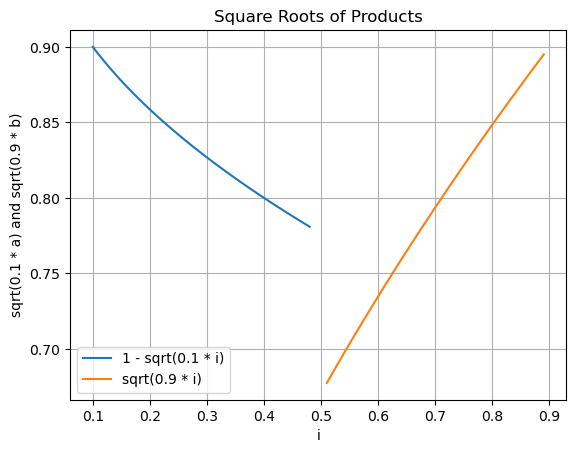

In [41]:
import matplotlib.pyplot as plt

a = np.arange(0.1, 0.49, 0.01)
b = np.arange(0.51, 0.9, 0.01)

roots_a = [1 - math.sqrt(0.1 * i) for i in a]
roots_b = [math.sqrt(0.9 * i) for i in b]
plt.plot(a, roots_a, label="1 - sqrt(0.1 * i)")
plt.plot(b, roots_b, label="sqrt(0.9 * i)")
plt.xlabel("i")
plt.ylabel("sqrt(0.1 * a) and sqrt(0.9 * b)")
plt.title("Square Roots of Products")
plt.legend()
plt.grid()
plt.show()


In [42]:
math.sqrt(0.4 * 0.7)

0.529150262212918

In [43]:
math.sqrt(0.6*0.3)

0.4242640687119285

# check per patch consistency saving

In [18]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/DO_a0005/predictions/test_predictions.h5"
consis_score = load_h5(path, "EI_consis")
consis_score_new = load_h5(path, "EI_consis_test")

In [19]:
consis_score_PP = np.array(
    np.nanmean(
        consis_score, axis=tuple(range(1, consis_score.ndim))
    )
)

/tmp/ipykernel_704193/2561076048.py:2: RuntimeWarning: Mean of empty slice
  np.nanmean(


In [20]:
consis_score_new.shape

(750,)

In [21]:
consis_score_PP.shape

(750,)

In [23]:
consis_score_PP[:10]

array([0.93911946, 0.95645946, 0.94209987, 0.9470443 , 0.9398319 ,
       0.9428695 , 0.9380186 , 0.9467523 , 0.94604665, 0.9152306 ],
      dtype=float32)

In [24]:
consis_score_new[:10]

array([0.93911946, 0.95645946, 0.94209987, 0.9470443 , 0.9398319 ,
       0.9428695 , 0.9380186 , 0.9467523 , 0.94604665, 0.9152306 ],
      dtype=float32)

In [25]:
diff_idx = np.where(
    ~((consis_score_PP == consis_score_new) | (np.isnan(consis_score_PP) & np.isnan(consis_score_new)))
)[0]
print(diff_idx)

[]


In [27]:
equal_or_nan = np.all((consis_score_new == consis_score_PP) | (np.isnan(consis_score_new) & np.isnan(consis_score_PP)))
print(equal_or_nan)

True


In [28]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_EPFL_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/DO_a0005/predictions/metric_summary.h5"
consis_score_PP = load_h5(path, "EI_consis")
consis_score_new = load_h5(path, "EI_consis_test")
equal_or_nan = np.all((consis_score_new == consis_score_PP) | (np.isnan(consis_score_new) & np.isnan(consis_score_PP)))
print(equal_or_nan)

True
